# DATA PRE-PROCESSING PIPELINE

### Libraries

In [1]:
!sudo apt-get update -qq
!sudo apt-get install -y texlive-latex-extra texlive-fonts-recommended dvipng cm-super


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-lato fonts-lmodern fonts-texgyre
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern pfb2t1c2pfb preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-loggin

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import warnings
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from __future__ import annotations
import os, re, math
from typing import Iterable, Set, Dict, Tuple, Sequence, List
from polars import selectors as cs
import polars as pl
from itertools import combinations

%config HistoryManager.enabled = False
warnings.filterwarnings('ignore')


In [3]:
# THESIS STYLE FOR PLOT
def apply_thesis_style(use_tex: bool = True,
                       legend_position: str = "upper right",
                       legend_outside: bool = False):
    """
    Applica uno stile uniforme (Matplotlib + Seaborn) coerente con LaTeX
    e definisce `place_legend()` per posizionare le legende in modo consistente.

    Parameters
    ----------
    use_tex : bool
        Se True, abilita il rendering LaTeX del testo (richiede TeX installato).
    legend_position : str
        Posizione di DEFAULT per le legende: 'upper right', 'upper left',
        'lower right', 'lower left', 'center', 'best' (accetta anche 'top/bottom').
    legend_outside : bool
        Se True, la legenda di default è fuori dal grafico (a destra).
    """
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import seaborn as sns

    # --- Normalizza la posizione di default ---
    def _normalize_pos(pos: str) -> str:
        if not isinstance(pos, str):
            return "upper right"
        key = pos.strip().lower().replace("top", "upper").replace("bottom", "lower")
        mapping = {
            "upper right": "upper right",
            "upper left":  "upper left",
            "lower right": "lower right",
            "lower left":  "lower left",
            "center":      "center",
            "best":        "best",
        }
        return mapping.get(key, "upper right")

    _default_loc = _normalize_pos(legend_position)

    # --- Tema Seaborn + rcParams coerenti con tesi ---
    sns.set_theme(style="whitegrid", context="notebook")
    mpl.rcParams.update({
        # Tipografia
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
        "mathtext.fontset": "cm",
        "text.usetex": bool(use_tex),

        # Dimensioni
        "figure.figsize": (6.8, 4.5),
        "font.size": 8.5,          # testo generico (plt.text, ecc.)
        "axes.labelsize": 10.5,    # etichette assi
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9.5,
        "legend.title_fontsize": 9.5,

        # Aspetto assi
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,

        # Stile legenda (default; può essere sovrascritto da place_legend)
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "#D0D0D0",
        "legend.loc": _default_loc,
        "legend.framealpha": 1.0,
        "legend.handlelength": 1.8,
        "legend.handletextpad": 0.6,
        "legend.borderpad": 0.4,
        "legend.borderaxespad": 0.8,
    })

    def place_legend(ax=None,
                     position: str | None = None,
                     outside: bool | None = None,
                     fontsize: float | None = None):
        """
        Posiziona la legenda su un asse con stile coerente tesi.

        Parameters
        ----------
        ax : matplotlib.axes.Axes, optional
            Asse su cui porre la legenda (default: asse corrente).
        position : str | None
            'upper right', 'upper left', 'lower right', 'lower left', 'center', 'best'.
            Se None, usa la posizione di default passata a apply_thesis_style().
            Spazi/maiuscole tollerati; 'top/bottom' mappati su 'upper/lower'.
        outside : bool | None
            Se True, mette la legenda fuori dal grafico (a destra).
            Se None, usa il valore di default passato a apply_thesis_style().
        fontsize : float | None
            Per cambiare la dimensione del font della legenda solo in questo plot.
        """
        import matplotlib as mpl
        import matplotlib.pyplot as plt

        if ax is None:
            ax = plt.gca()

        # Normalizza posizione richiesta o usa default globale
        loc_val = _default_loc
        if isinstance(position, str):
            key = position.strip().lower().replace("top", "upper").replace("bottom", "lower")
            loc_map = {
                "upper right": "upper right",
                "upper left":  "upper left",
                "lower right": "lower right",
                "lower left":  "lower left",
                "center":      "center",
                "best":        "best",
            }
            loc_val = loc_map.get(key, _default_loc)

        # outside: se None, eredita da default; altrimenti usa l'override
        outside = (legend_outside if outside is None else bool(outside))

        # Costruisci kwargs coerenti con rcParams
        legend_kwargs = dict(
            loc=loc_val,
            frameon=True,
            facecolor="white",
            edgecolor=mpl.rcParams["legend.edgecolor"],
            framealpha=1.0,
            fontsize=mpl.rcParams["legend.fontsize"] if fontsize is None else fontsize,
            handlelength=1.8,
            handletextpad=0.6,
            borderpad=0.4,
            fancybox=False,
        )

        if outside:
            legend_kwargs.update({
                "bbox_to_anchor": (1.02, 1.0),
                "borderaxespad": 0.0,
            })

        leg = ax.legend(**legend_kwargs)
        if leg is not None:
            leg.get_frame().set_linewidth(0.8)
            leg.get_frame().set_edgecolor(mpl.rcParams["legend.edgecolor"])
            leg.get_frame().set_facecolor("white")
        return ax

    # Esporta l’helper nel namespace globale del notebook/script
    globals()["place_legend"] = place_legend


## STEP 0 — Initial Pre-processing

## CELL 0.1 — Load β-matrix and phenotype table

In [4]:
# LOAD BETA AND PHENOTYPE TABLES
# Load beta-value matrix (Parquet) and phenotype table, check alignment and basic issues.
BETA_PATH = "/kaggle/input/3-gse287331-parquet/GSE287331_clean_imputed.parquet"     
PHENO_PATH = "/kaggle/input/1-pheno-gse287331-parquet/pheno_GSE287331.parquet"    

# Read Parquet files
beta_pl = pl.read_parquet(BETA_PATH)              # Load beta matrix
pheno_pl = pl.read_parquet(PHENO_PATH)            # Load phenotype metadata

print(f"beta_pl.shape: {beta_pl.shape}")
print(f"pheno_pl.shape: {pheno_pl.shape}")


beta_pl.shape: (446, 703168)
pheno_pl.shape: (446, 5)


## CELL 0.2 — Basic sanity checks

In [5]:
# BASIC CHECKS ON PHENOTYPE TABLE
# Verify unique sample IDs, missing values, and expected fields.
# Check for duplicated id_tissue in phenotype
dup_ids = pheno_pl["id_tissue"].is_duplicated().any()
if dup_ids:
    raise ValueError("Duplicated sample IDs found in phenotype table.")

# Check required fields
required_cols = ["id_tissue", "label"]
missing_cols = [c for c in required_cols if c not in pheno_pl.columns]
if missing_cols:
    raise KeyError(f"Missing required phenotype columns: {missing_cols}")

pheno_pl.head()


id_tissue,sample_name,tissue_type_raw,label,idat_basename
str,str,str,i8,str
"""GSM8744013""","""HDB_K105022""","""HDB""",0,"""202234810048_R01C01"""
"""GSM8744014""","""HDB_K107274""","""HDB""",0,"""202234810048_R02C01"""
"""GSM8744015""","""HDB_K105903""","""HDB""",0,"""202234810048_R03C01"""
"""GSM8744016""","""HDB_K106028""","""HDB""",0,"""202234810048_R04C01"""
"""GSM8744017""","""HDB_K104729""","""HDB""",0,"""202234810048_R05C01"""


## CELL 0.3 — Harmonize phenotype with β-matrix

In [6]:
# ALIGN PHENOTYPE AND BETA MATRIX
# Keep only samples present in both tables to ensure consistent joint analysis.

# Extract sample IDs from beta matrix
beta_ids = beta_pl["id_tissue"].to_list()
pheno_ids = pheno_pl["id_tissue"].to_list()

# Intersect sample IDs
shared = set(beta_ids).intersection(pheno_ids)
print("Shared samples:", len(shared))

# Filter both tables
beta_pl = beta_pl.filter(pl.col("id_tissue").is_in(shared))
pheno_pl = pheno_pl.filter(pl.col("id_tissue").is_in(shared))


Shared samples: 446


## CELL 0.4 — Check Missingness

In [7]:
# CHECK MISSINGNESS (QUICK DIAGNOSTIC)
# Verify if any missing values are present—datasets should be complete.

cpg_cols = [c for c in beta_pl.columns if c not in ["id_tissue", "label"]]

# Count missing values per CpG (column-wise)
n_missing_cpgs = (
    beta_pl.select([pl.col(c).is_null().sum().alias(c) for c in cpg_cols])
    .to_pandas()
    .sum()
    .sum()
)

# Count missing values per sample (row-wise)
n_missing_samples = (
    beta_pl
    .select(pl.sum_horizontal(pl.all().exclude(["id_tissue", "label"]).is_null()).alias("na_per_sample"))
    ["na_per_sample"]
    .sum()
)

# Print diagnostic summary
if n_missing_cpgs == 0 and n_missing_samples == 0:
    print("✓ No missing values detected — dataset is complete.")
else:
    print(f"Missing CpG entries: {int(n_missing_cpgs)}")
    print(f"Missing sample entries: {int(n_missing_samples)}")


✓ No missing values detected — dataset is complete.


## CELL 0.5 — Type I / Type II probe distribution diagnostic (no BMIQ yet)

Collected CpGs → Type I: 115,705   Type II: 585,514


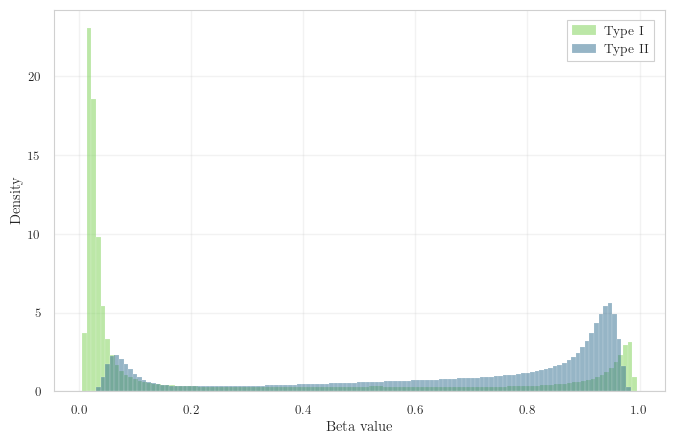

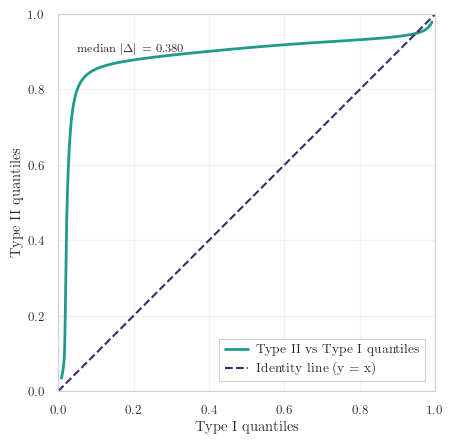

Median absolute deviation from identity (Q–Q): 0.3798 (lower ≈ better alignment)


In [8]:
# TYPE-I / TYPE-II BIAS DIAGNOSTIC 
# Uses ALL CpGs (Type I & Type II) present in your Polars matrix
PROBE_MAP_CSV = "/kaggle/input/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"  

# Load matrix (as LazyFrame) 
LF = beta_pl.lazy() if isinstance(beta_pl, pl.DataFrame) else beta_pl
schema_cols = list(LF.schema.keys())

# Detect CpG columns (wide format: Samples x CpGs, CpGs = columns)
cpg_cols = [c for c in schema_cols if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
if not cpg_cols:
    raise ValueError("No CpG-like columns found (expected columns starting with 'cg' or 'ch').")

# READ EPIC MANIFEST AND MAP CPG TO INFNIUM DESIGN TYPE
# We parse the CSV manually and keep only IlmnID and Infinium_Design_Type
import csv

rows = []
with open(PROBE_MAP_CSV, newline="") as f:
    reader = csv.reader(f)
    # Skip Illumina metadata and reach the header row
    for _ in range(7):
        next(reader, None)
    header = next(reader)

    # Find column indices for IlmnID and Infinium_Design_Type
    try:
        idx_ilmn = header.index("IlmnID")
        idx_type = header.index("Infinium_Design_Type")
    except ValueError as e:
        raise RuntimeError(f"Could not find IlmnID / Infinium_Design_Type in manifest header: {header}") from e

    # Iterate over remaining lines and collect only cg probes with valid type
    for row in reader:
        if len(row) <= max(idx_ilmn, idx_type):
            continue
        ilmn = row[idx_ilmn].strip()
        t    = row[idx_type].strip()
        if not ilmn.startswith("cg"):
            continue
        if t not in ("I", "II"):
            continue
        rows.append((ilmn, t))

probe_map = pl.DataFrame(rows, schema=["CpG", "Type"])

# Intersect with CpGs present in the matrix
typeI_cpgs  = set(probe_map.filter(pl.col("Type") == "I")["CpG"].to_list())  & set(cpg_cols)
typeII_cpgs = set(probe_map.filter(pl.col("Type") == "II")["CpG"].to_list()) & set(cpg_cols)

if not typeI_cpgs or not typeII_cpgs:
    raise ValueError("Type I or Type II CpG sets are empty after intersecting with your matrix columns.")

# Collect all values per Type (no subsampling)
def collect_values_for(cpg_set: Iterable[str]) -> np.ndarray:
    cols = sorted(list(cpg_set))
    # Collect as 2D (Samples x CpGs) then flatten; keep finite values in [0,1]
    M = LF.select(cols).collect(streaming=True).to_numpy()
    vec = M.ravel()
    vec = vec[np.isfinite(vec)]
    return vec[(vec >= 0.0) & (vec <= 1.0)]

vals_I  = collect_values_for(typeI_cpgs)
vals_II = collect_values_for(typeII_cpgs)

print(f"Collected CpGs → Type I: {len(typeI_cpgs):,}   Type II: {len(typeII_cpgs):,}")

# Build figure 
apply_thesis_style(use_tex=True)
cmap = plt.cm.get_cmap("viridis")

# Overlaid density via normalized histograms
plt.figure()
plt.hist(
    vals_I,
    bins=120,
    density=True,
    alpha=0.50,
    label="Type I",
    color=cmap(0.80),
    edgecolor="white",
    linewidth=0.2,
)
plt.hist(
    vals_II,
    bins=120,
    density=True,
    alpha=0.50,
    label="Type II",
    color=cmap(0.35),
    edgecolor="white",
    linewidth=0.2,
)
plt.xlabel("Beta value")
plt.ylabel("Density")
place_legend(position="upper right")
plt.tight_layout()
plt.savefig("type_bias_density.pdf", bbox_inches="tight")
plt.show()

# Q–Q plot (Type II quantiles vs Type I)
q   = np.linspace(0.001, 0.999, 500)
qI  = np.quantile(vals_I,  q)
qII = np.quantile(vals_II, q)
mad = float(np.median(np.abs(qII - qI)))  # alignment metric

plt.figure()
plt.plot(qI, qII, lw=2, color=cmap(0.55), label="Type II vs Type I quantiles")
plt.plot([0, 1], [0, 1], ls="--", color=cmap(0.10), label="Identity line (y = x)")
plt.xlabel("Type I quantiles")
plt.ylabel("Type II quantiles")
ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.text(0.05, 0.90, f"median $|\\Delta|$ = {mad:.3f}", transform=ax.transAxes)
place_legend(ax, "lower right")
plt.tight_layout()
plt.savefig("type_bias_qqplot.pdf", bbox_inches="tight")
plt.show()

print(f"Median absolute deviation from identity (Q–Q): {mad:.4f} (lower ≈ better alignment)")


## STEP 1 — Technical filtering

### CELL 1.1 — Technical filtering imports and paths

In [9]:
# TECHNICAL FILTERING IMPORTS AND PATHS
# Import required modules and define paths to external technical probe lists.

# Paths to external technical probe lists (update paths if needed)
NAEEM_CSV        = "/kaggle/input/filtering-cpg-naeem/filtering_table.csv"                       # Naeem 2014
PIDSLEY_CSV      = "/kaggle/input/filtering-cpg-pidsley/Chen2013_full_blacklist.csv"             # Pidsley 2016
CHEN_CROSS_CSV   = "/kaggle/input/filtering-cpg-chen-cross-reactive/chen_2013_cross_reactive.csv"  # Chen 2013
ZHOU_TSV         = "/kaggle/input/filtering-cpg-zhou/EPIC.anno.GRCh38.tsv"                       # Zhou 2016
MCCARTNEY_CROSS_CPG   = "/kaggle/input/filtering-cpg-mccartney-2/1-s2.0-S221359601630071X-mmc2.txt"   # McCartney 2016 file 2 (CpG cross-hyb)
MCCARTNEY_CROSS_NONCG = "/kaggle/input/filtering-cpg-mccartney-3/1-s2.0-S221359601630071X-mmc3.txt"   # McCartney 2016 file 3 (non-CpG cross-hyb)


### CELL 1.2 — Helper and Inspection analysis

In [10]:
# HELPER FUNCTIONS FOR TECHNICAL PROBE LISTS
# Define robust loaders for Naeem, Pidsley, Chen, Zhou, McCartney lists.

def load_naeem_drop_set(
    path: str,
    probe_cands: Iterable[str] = ("probe", "IlmnID", "ID_REF", "cg", "Name"),
    flag_cands: Iterable[str] = ("Flag(discard/keep)", "flag(discard/keep)", "flag", "flag_discard_keep"),
) -> Set[str]:
    """Return probes flagged as 'discard' in Naeem table."""
    df = pl.read_csv(path)
    probe_col = next((c for c in probe_cands if c in df.columns), None)
    flag_col = next((c for c in df.columns if str(c).lower().strip().startswith("flag")), None) \
               or next((c for c in flag_cands if c in df.columns), None)
    assert probe_col and flag_col, f"Naeem file columns not found. Seen: {df.columns}"

    probes = df[probe_col].cast(pl.Utf8).str.strip_chars()
    flags = df[flag_col].cast(pl.Utf8).str.to_lowercase()

    return set(probes.filter(flags.str.contains("discard")).to_list())


def load_pidsley_drop_set(path: str, skip_first_lines: int = 1) -> Set[str]:
    """Robust loader for Pidsley full blacklist."""
    df_comma = pl.read_csv(
        path,
        has_header=True,
        infer_schema_length=10000,
        separator=",",
        skip_rows=skip_first_lines,
    )
    try:
        df_tab = pl.read_csv(
            path,
            has_header=True,
            infer_schema_length=10000,
            separator="\t",
            skip_rows=skip_first_lines,
        )
    except Exception:
        df_tab = None

    cand = df_tab if (df_tab is not None and df_tab.width > df_comma.width) else df_comma

    cpg_like_cols = [
        c for c in cand.columns
        if ("cg" in str(c).lower())
        or ("ilmn" in str(c).lower())
        or ("probe" in str(c).lower())
        or ("id" in str(c).lower())
    ]
    if not cpg_like_cols:
        cpg_like_cols = [cand.columns[0]]

    series_list = cand.select(
        pl.concat_list([pl.col(c).cast(pl.Utf8) for c in cpg_like_cols]).alias("_u")
    ).to_series()

    s = series_list.explode().cast(pl.Utf8).str.strip_chars()
    values = s.to_list()
    return set(x for x in values if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))


def load_firstcol_probe_list(path: str) -> Set[str]:
    """
    Robust 'first column' loader for simple lists (e.g. McCartney).
    Keeps ONLY the first column; returns cg*/ch* IDs.
    """
    def _try_read(sep: str, has_header: bool):
        return pl.read_csv(path, separator=sep, has_header=has_header, infer_schema_length=10000)

    df = None
    for sep in (",", "\t"):
        for hh in (True, False):
            try:
                df = _try_read(sep, hh)
                break
            except Exception:
                df = None
        if df is not None:
            break

    if df is None:  # Last resort
        df = pl.read_csv(path, infer_schema_length=10000)

    first_col = df.columns[0]
    s = df[first_col].cast(pl.Utf8).str.strip_chars()
    vals = s.to_list()

    return set(x for x in vals if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))


def load_chen_crossreactive_firstcol(path: str) -> Set[str]:
    """Chen 2013 cross-reactive list: CSV; keep ONLY the first column with probe IDs."""
    df = pl.read_csv(path, has_header=True, infer_schema_length=10000, separator=",")
    first_col = df.columns[0]
    s = df[first_col].cast(pl.Utf8).str.strip_chars()
    vals = s.to_list()

    return set(x for x in vals if isinstance(x, str) and (x.startswith("cg") or x.startswith("ch")))


def zhou_mask_ids(
    tsv_path: str,
    id_col_candidates: Iterable[str] = ("probeID", "IlmnID", "Name"),
) -> Set[str]:
    """
    Read only ID + MASK_* columns from Zhou TSV and return probes to mask.
    A probe is 'bad' if ANY MASK_* column is true.
    """
    hdr = pl.read_csv(tsv_path, separator="\t", has_header=True, n_rows=1, ignore_errors=True)
    id_col = next((c for c in id_col_candidates if c in hdr.columns), None)
    assert id_col, f"ID column not found in Zhou TSV. Seen: {hdr.columns}"

    mask_cols = [c for c in hdr.columns if str(c).upper().startswith("MASK")]
    assert mask_cols, "No MASK_* columns found in Zhou TSV."

    df = pl.read_csv(
        tsv_path,
        separator="\t",
        has_header=True,
        columns=[id_col] + mask_cols,
        dtypes={id_col: pl.Utf8},
        ignore_errors=True,
    )

    truthy = {"true", "1", "t", "yes", "y"}
    falsy = {"false", "0", "f", "no", "n", ""}

    def mask_to_bool(colname: str) -> pl.Expr:
        s = pl.col(colname).cast(pl.Utf8).str.to_lowercase()
        return (
            pl.when(s.is_in(list(truthy))).then(True)
              .when(s.is_in(list(falsy))).then(False)
              .otherwise(False)
              .alias(colname)
        )

    df_norm = df.select(
        [pl.col(id_col).cast(pl.Utf8).str.strip_chars().alias(id_col)]
        + [mask_to_bool(c) for c in mask_cols]
    )

    mask_any = pl.any_horizontal([pl.col(c) for c in mask_cols])
    bad = df_norm.filter(mask_any)[id_col].to_list()

    return set(bad)


In [11]:
# INITIALIZE FILTERING STATS AND HELPER FOR CPG COLUMNS
# Prepare stats dictionary and a small utility to get CpG columns from beta matrix.

def get_cpg_cols(df: pl.DataFrame) -> list[str]:
    """Return CpG columns (all columns except id_tissue and label)."""
    return [c for c in df.columns if c not in ["id_tissue", "label"]]

initial_cpgs = [
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]

filter_stats: Dict[str, int] = {
    "initial_cpgs": len(initial_cpgs),
    "removed_naeem": 0,
    "removed_pidsley": 0,
    "removed_zhou": 0,
    "removed_chenx": 0,
    "removed_mccartney": 0,
    "removed_non_cpg": 0,
    "removed_xy": 0,
}


In [12]:
# LOAD AND INTERSECT TECHNICAL PROBE LISTS
# Load Naeem, Pidsley, Zhou, Chen-X, McCartney and intersect with CpGs present in beta matrix.

# CpG columns present in the current beta matrix (column-wise layout)
cpg_cols_beta = [
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]
present_cpgs = set(cpg_cols_beta)

print(f"Number of CpGs in beta matrix: {len(present_cpgs):,}")
print("Loading technical filter lists...")

# Load full lists (universe) from external sources
S_naeem_all      = load_naeem_drop_set(NAEEM_CSV)
S_pidsley_all    = load_pidsley_drop_set(PIDSLEY_CSV)
S_zhou_all       = zhou_mask_ids(ZHOU_TSV)
S_chenx_all      = load_chen_crossreactive_firstcol(CHEN_CROSS_CSV)
S_mccartney2_all = load_firstcol_probe_list(MCCARTNEY_CROSS_CPG)
S_mccartney3_all = load_firstcol_probe_list(MCCARTNEY_CROSS_NONCG)
S_mccartney_all  = S_mccartney2_all | S_mccartney3_all

# Intersect each list with CpGs present in the beta matrix
S_naeem      = S_naeem_all      & present_cpgs
S_pidsley    = S_pidsley_all    & present_cpgs
S_zhou       = S_zhou_all       & present_cpgs
S_chenx      = S_chenx_all      & present_cpgs
S_mccartney  = S_mccartney_all  & present_cpgs

filter_stats["removed_naeem"]     = len(S_naeem)
filter_stats["removed_pidsley"]   = len(S_pidsley)
filter_stats["removed_zhou"]      = len(S_zhou)
filter_stats["removed_chenx"]     = len(S_chenx)
filter_stats["removed_mccartney"] = len(S_mccartney)

print("\nTechnical probe sets — overlap with current beta matrix:")
print(f"• Naeem 2014 (discard flag)                → in beta: {len(S_naeem):,}      / total in list: {len(S_naeem_all):,}")
print(f"• Pidsley (Chen2013 full blacklist)        → in beta: {len(S_pidsley):,}    / total in list: {len(S_pidsley_all):,}")
print(f"• Zhou 2016 (MASK_*)                       → in beta: {len(S_zhou):,}       / total in list: {len(S_zhou_all):,}")
print(f"• Chen 2013 (cross-reactive)               → in beta: {len(S_chenx):,}      / total in list: {len(S_chenx_all):,}")
print(f"• McCartney 2016 (cross-hyb CpG+non-CpG)   → in beta: {len(S_mccartney):,}  / total in list: {len(S_mccartney_all):,}")


Number of CpGs in beta matrix: 702,918
Loading technical filter lists...

Technical probe sets — overlap with current beta matrix:
• Naeem 2014 (discard flag)                → in beta: 124,511      / total in list: 190,672
• Pidsley (Chen2013 full blacklist)        → in beta: 8,992    / total in list: 67,030
• Zhou 2016 (MASK_*)                       → in beta: 102,802       / total in list: 193,182
• Chen 2013 (cross-reactive)               → in beta: 1,730      / total in list: 29,233
• McCartney 2016 (cross-hyb CpG+non-CpG)   → in beta: 3,672  / total in list: 44,208


### CELL 1.3 — Apply technical list filtering

In [13]:
# APPLY TECHNICAL LIST FILTERING TO BETA MATRIX
# Remove union of Naeem, Pidsley, Zhou, ChenX, McCartney probes from beta matrix.

removed_cpgs_technical = S_naeem | S_pidsley | S_zhou | S_chenx | S_mccartney
print("\nTotal technical CpGs to remove (union of all lists):", f"{len(removed_cpgs_technical):,}")

# Apply filtering to beta matrix columns
keep_cols = [c for c in beta_pl.columns if c not in removed_cpgs_technical]
beta_pl = beta_pl.select(keep_cols)  # Keep id_tissue, label, and unfiltered CpGs

print("\nBeta matrix shape after technical list filtering:")
print("  Samples:", beta_pl.height)
print("  Columns:", len(beta_pl.columns))
print("  Remaining CpGs:", len([c for c in beta_pl.columns if c.startswith('cg') or c.startswith('ch')]))

# Save removed technical CpGs (optional but useful for reproducibility)
pl.DataFrame({"CpG_ID": sorted(removed_cpgs_technical)}).write_csv("removed_cpgs_technical_filtering.csv")
print("Saved removed technical CpGs to 'removed_cpgs_technical_filtering.csv'.")



Total technical CpGs to remove (union of all lists): 203,114

Beta matrix shape after technical list filtering:
  Samples: 446
  Columns: 500054
  Remaining CpGs: 499804
Saved removed technical CpGs to 'removed_cpgs_technical_filtering.csv'.


### CELL 1.4 — Overlap Analysis

In [14]:
# OVERLAP ANALYSIS BETWEEN TECHNICAL PROBE LISTS
# Compute simple and exclusive overlaps between Naeem, Pidsley, Zhou, ChenX, McCartney.

tech_sets = {
    "Naeem": S_naeem,
    "Pidsley": S_pidsley,
    "Zhou": S_zhou,
    "ChenX": S_chenx,
    "McCartney": S_mccartney,
}
list_names = list(tech_sets.keys())

# Simple intersections (non-exclusive)
simple_overlap_rows: List[Dict[str, object]] = []

for r in range(1, len(list_names) + 1):
    for combo in combinations(list_names, r):
        combo_sets = [tech_sets[name] for name in combo]
        inter = set.intersection(*combo_sets) if combo_sets else set()
        simple_overlap_rows.append(
            {
                "lists": " ∩ ".join(combo),
                "n_lists": r,
                "n_cpgs_intersection": len(inter),
            }
        )

simple_overlap_df = (
    pl.DataFrame(simple_overlap_rows)
    .sort(["n_lists", "n_cpgs_intersection"], descending=[False, True])
)

print("=== Simple intersections (non-exclusive) ===")
print(simple_overlap_df)

# Exclusive intersections
exclusive_overlap_rows: List[Dict[str, object]] = []

for r in range(1, len(list_names) + 1):
    for combo in combinations(list_names, r):
        combo_sets = [tech_sets[name] for name in combo]
        inter = set.intersection(*combo_sets) if combo_sets else set()

        other_sets = [tech_sets[name] for name in list_names if name not in combo]
        others_union = set.union(*other_sets) if other_sets else set()

        exclusive = inter - others_union

        exclusive_overlap_rows.append(
            {
                "lists": " ∩ ".join(combo),
                "n_lists": r,
                "n_cpgs_exclusive": len(exclusive),
            }
        )

exclusive_overlap_df = (
    pl.DataFrame(exclusive_overlap_rows)
    .sort(["n_lists", "n_cpgs_exclusive"], descending=[False, True])
)

print("\n=== Exclusive intersections (only in that combination, not in others) ===")
print(exclusive_overlap_df)


=== Simple intersections (non-exclusive) ===
shape: (31, 3)
┌─────────────────────────────────┬─────────┬─────────────────────┐
│ lists                           ┆ n_lists ┆ n_cpgs_intersection │
│ ---                             ┆ ---     ┆ ---                 │
│ str                             ┆ i64     ┆ i64                 │
╞═════════════════════════════════╪═════════╪═════════════════════╡
│ Naeem                           ┆ 1       ┆ 124511              │
│ Zhou                            ┆ 1       ┆ 102802              │
│ Pidsley                         ┆ 1       ┆ 8992                │
│ McCartney                       ┆ 1       ┆ 3672                │
│ ChenX                           ┆ 1       ┆ 1730                │
│ …                               ┆ …       ┆ …                   │
│ Pidsley ∩ Zhou ∩ ChenX ∩ McCar… ┆ 4       ┆ 216                 │
│ Naeem ∩ Pidsley ∩ Zhou ∩ McCar… ┆ 4       ┆ 170                 │
│ Naeem ∩ Pidsley ∩ Zhou ∩ ChenX  ┆ 4       ┆ 162       

### CELL 1.5 — Annotation-based filtering

In [15]:
# LOAD ILLUMINA EPIC MANIFEST
# Load Infinium MethylationEPIC v1.0 B5 manifest and normalize probe ID and chromosome columns.

# Infinium MethylationEPIC v1.0 B5 Manifest File
MANIFEST_CSV = "/kaggle/input/manifest-infinium-methylationepic-cpg-to-gene/infinium-methylationepic-v-1-0-b5-manifest-file.csv"

def find_assay_skiprows(csv_path: str) -> int:
    """Return number of rows to skip so that the next row is the assay header (IlmnID,Name,...)."""
    skip = 0
    with open(csv_path, "r", encoding="utf-8", errors="ignore") as fh:
        for i, line in enumerate(fh):
            if line.strip().startswith("[Assay]"):
                skip = i + 1
                break
    return skip

skip_rows = find_assay_skiprows(MANIFEST_CSV)

manifest = pl.read_csv(
    MANIFEST_CSV,
    skip_rows=skip_rows,
    has_header=True,
    infer_schema_length=2000,
    separator=",",
    ignore_errors=True,
)

PROBE_ID_COL_CANDS = ("IlmnID", "Name")
CHR_COL_CANDS      = ("CHR", "Chromosome")

PROBE_ID_COL = next((c for c in PROBE_ID_COL_CANDS if c in manifest.columns), None)
CHR_COL      = next((c for c in CHR_COL_CANDS      if c in manifest.columns), None)

if PROBE_ID_COL is None:
    raise KeyError(f"Probe ID column not found in manifest. Seen: {manifest.columns}")

manifest = manifest.with_columns(
    pl.col(PROBE_ID_COL).cast(pl.Utf8).str.strip_chars().alias("probe_id")
)

if CHR_COL:
    manifest = manifest.with_columns(
        pl.col(CHR_COL)
        .cast(pl.Utf8)
        .str.strip_chars()
        .str.replace(r"(?i)^chr", "", literal=False)
        .str.to_uppercase()
        .alias("chrom_std")
    )
else:
    manifest = manifest.with_columns(pl.lit(None).cast(pl.Utf8).alias("chrom_std"))


In [16]:
# REMOVE NON-CPG PROBES (CHH/CHG, 'ch*') using EPIC manifest

current_cpgs_after_lists = set(
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
)

manifest_subset_non_cpg = manifest.filter(
    pl.col("probe_id").is_in(list(current_cpgs_after_lists))
)

name_col = "Name" if "Name" in manifest_subset_non_cpg.columns else None

# Correct Polars syntax: .str.starts_with()
if name_col:
    non_cpg_mask = (
        pl.col(name_col)
        .cast(pl.Utf8)
        .str.to_lowercase()
        .str.starts_with("ch")      
    )
else:
    non_cpg_mask = (
        pl.col("probe_id")
        .cast(pl.Utf8)
        .str.to_lowercase()
        .str.starts_with("ch")    
    )

non_cpg_ids = set(
    manifest_subset_non_cpg
    .with_columns(non_cpg_mask.alias("is_non_cpg"))
    .filter(pl.col("is_non_cpg"))
    ["probe_id"]
    .to_list()
)

non_cpg_in_beta = non_cpg_ids & current_cpgs_after_lists
filter_stats["removed_non_cpg"] = len(non_cpg_in_beta)

print("Non-CpG probes to remove (CHH/CHG / 'ch*'):", len(non_cpg_in_beta))

if non_cpg_in_beta:
    beta_pl = beta_pl.drop(list(non_cpg_in_beta))

print("Remaining CpGs after non-CpG filtering:", len(get_cpg_cols(beta_pl)))


Non-CpG probes to remove (CHH/CHG / 'ch*'): 500
Remaining CpGs after non-CpG filtering: 499552


### CELL 1.6 — Remove X and Y chromosome probes

In [17]:
# REMOVE X AND Y CHROMOSOME PROBES
# Remove CpGs on sex chromosomes (X and Y) to avoid sex-related confounding.

if "chrom_std" not in manifest.columns:
    raise KeyError("chrom_std column not found in manifest; check manifest loading step.")

cpg_cols_current = set(
    c for c in beta_pl.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
)

manifest_subset_xy = manifest.filter(pl.col("probe_id").is_in(list(cpg_cols_current)))

xy_ids = set(
    manifest_subset_xy
    .filter(pl.col("chrom_std").is_in(["X", "Y"]))
    ["probe_id"]
    .to_list()
)

xy_in_beta = xy_ids & cpg_cols_current
filter_stats["removed_xy"] = len(xy_in_beta)

print("CpGs removed on chromosomes X/Y:", len(xy_in_beta))

if xy_in_beta:
    beta_pl = beta_pl.drop(list(xy_in_beta))

print("Remaining CpGs after X/Y filtering:", len(get_cpg_cols(beta_pl)))


CpGs removed on chromosomes X/Y: 12579
Remaining CpGs after X/Y filtering: 486973


### CELL 1.7 — Technical filtering summary

In [18]:
# TECHNICAL FILTERING SUMMARY
# Summarize number of CpGs removed at each step and final dimensionality.

filter_stats["final_cpgs"] = len(
    [c for c in beta_pl.columns if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))]
)

print("\n=== Technical Filtering Summary ===")
print(f"Initial CpGs:          {filter_stats['initial_cpgs']:,}")
print(f"Removed (Naeem):       {filter_stats['removed_naeem']:,}")
print(f"Removed (Pidsley):     {filter_stats['removed_pidsley']:,}")
print(f"Removed (Zhou):        {filter_stats['removed_zhou']:,}")
print(f"Removed (ChenX):       {filter_stats['removed_chenx']:,}")
print(f"Removed (McCartney):   {filter_stats['removed_mccartney']:,}")
print(f"Removed (Non-CpG):     {filter_stats['removed_non_cpg']:,}")
print(f"Removed (X/Y):         {filter_stats['removed_xy']:,}")
print(f"Final CpGs:            {filter_stats['final_cpgs']:,}")
print("==================================")



=== Technical Filtering Summary ===
Initial CpGs:          702,918
Removed (Naeem):       124,511
Removed (Pidsley):     8,992
Removed (Zhou):        102,802
Removed (ChenX):       1,730
Removed (McCartney):   3,672
Removed (Non-CpG):     500
Removed (X/Y):         12,579
Final CpGs:            486,725


In [19]:
# SAVE REMOVED CPGS WITH REASONS
# Build a summary table with all removed CpGs and which filters flagged them.

# Union of all removed CpGs across all technical filters
all_removed_cpgs = (
    S_naeem
    | S_pidsley
    | S_zhou
    | S_chenx
    | S_mccartney
    | non_cpg_in_beta
    | xy_in_beta
)

print(f"Total unique removed CpGs across all filters: {len(all_removed_cpgs):,}")

# Build per-CpG reason flags
rows = []
for cg in sorted(all_removed_cpgs):
    rows.append(
        {
            "CpG_ID": cg,
            "From_Naeem": int(cg in S_naeem),
            "From_Pidsley": int(cg in S_pidsley),
            "From_Zhou": int(cg in S_zhou),
            "From_ChenX": int(cg in S_chenx),
            "From_McCartney": int(cg in S_mccartney),
            "From_Non_CpG": int(cg in non_cpg_in_beta),
            "From_XY": int(cg in xy_in_beta),
        }
    )

removed_summary_df = pl.DataFrame(rows).with_columns(
    (
        pl.col("From_Naeem")
        + pl.col("From_Pidsley")
        + pl.col("From_Zhou")
        + pl.col("From_ChenX")
        + pl.col("From_McCartney")
        + pl.col("From_Non_CpG")
        + pl.col("From_XY")
    ).alias("Source_Count")
)

# Optional: sort by Source_Count (descending) and then CpG_ID
removed_summary_df = removed_summary_df.sort(
    ["Source_Count", "CpG_ID"], descending=[True, False]
)

# Save to CSV
removed_summary_df.write_csv("removed_cpgs_all_filters_summary.csv")

print("\nArtifacts:")
print("  • Saved per-CpG removal summary to 'removed_cpgs_all_filters_summary.csv'")
print("    (columns: CpG_ID + Naeem, Pidsley, Zhou, ChenX, McCartney, Non_CpG, XY, Source_Count)")


Total unique removed CpGs across all filters: 216,193

Artifacts:
  • Saved per-CpG removal summary to 'removed_cpgs_all_filters_summary.csv'
    (columns: CpG_ID + Naeem, Pidsley, Zhou, ChenX, McCartney, Non_CpG, XY, Source_Count)


## STEP 2 — Conversion β → M 

### CELL 2.1 —

In [20]:
# DEFINE BETA_CLEAN MATRIX
# Set beta_clean as the post-technical filtering beta matrix (N + A + T).

beta_clean = beta_pl  # From Step 1
beta_cpg_cols = [
    c for c in beta_clean.columns
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]
meta_cols = [c for c in ("id_tissue", "label") if c in beta_clean.columns]

print("beta_clean shape:", beta_clean.shape)
print("beta_clean samples:", beta_clean.height)
print("beta_clean CpGs:", len(beta_cpg_cols))
print("beta_clean meta columns:", meta_cols)


beta_clean shape: (446, 486975)
beta_clean samples: 446
beta_clean CpGs: 486725
beta_clean meta columns: ['id_tissue', 'label']


In [21]:
# DEFINE EPS AND M-VALUE TRANSFORM
# Ensure EPS and compute_M_expr are defined for Beta → M conversion.

import polars as pl
import numpy as np

if "EPS" not in globals():
    EPS = 1e-6  # Numeric stability for Beta→M

def compute_M_expr(colname: str, eps: float = EPS) -> pl.Expr:
    """
    Compute M-value expression for a given CpG column:
    M = log2( (beta + eps) / (1 - beta + eps) ).
    Returns a Polars expression suitable for with_columns().
    """
    b = pl.col(colname).cast(pl.Float64)
    b = b.clip(eps, 1.0 - eps)
    return ((b + eps) / (1.0 - b + eps)).log(2.0).cast(pl.Float32)


In [22]:
# PREPARE CPG COLUMNS AND LAZYFRAME
# Identify CpG columns and construct a LazyFrame from beta_clean.

beta_schema_cols = list(beta_clean.columns)
cpg_cols = [
    c for c in beta_schema_cols
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]

assert len(cpg_cols) > 0, "No CpG columns found in beta_clean."
assert "id_tissue" in beta_schema_cols and "label" in beta_schema_cols, "Expected 'id_tissue' and 'label' in beta_clean."

lf_beta_clean = beta_clean.lazy()
print(f"CpG columns to be transformed to M-values: {len(cpg_cols)}")


CpG columns to be transformed to M-values: 486725


In [23]:
# BUILD M_clean LAZYFRAME
# Apply Beta → M transformation to all CpG columns, keeping metadata unchanged.

m_exprs = [compute_M_expr(c).alias(c) for c in cpg_cols]

M_clean = lf_beta_clean.with_columns(m_exprs)

print("M_clean LazyFrame defined (same schema as beta_clean for CpGs).")


M_clean LazyFrame defined (same schema as beta_clean for CpGs).


In [24]:
# SAVE M_clean TO PARQUET
# Save M_clean as Parquet (LZ4) without fully materializing if possible.

OUT_PARQUET_M = "/kaggle/working/M_values_clean_lz4.parquet"

try:
    M_clean.sink_parquet(OUT_PARQUET_M, compression="lz4", maintain_order=True)
    print(f"Saved M_clean to Parquet (sink_parquet): {OUT_PARQUET_M}")
except Exception as e:
    print(f"Warning: sink_parquet failed with {e}. Falling back to collect().")
    df_m = M_clean.collect(streaming=True)
    df_m.write_parquet(OUT_PARQUET_M, compression="lz4")
    del df_m
    print(f"Saved M_clean to Parquet via collect(): {OUT_PARQUET_M}")


Saved M_clean to Parquet (sink_parquet): /kaggle/working/M_values_clean_lz4.parquet


In [25]:
# OPTIONAL MATERIALIZATION CHECK
# Collect a small sample to verify that M_clean looks reasonable.

M_head = M_clean.select(meta_cols + cpg_cols[:5]).collect().head(3)
print("Preview of M_clean (first 3 samples, first 5 CpGs):")
print(M_head)


Preview of M_clean (first 3 samples, first 5 CpGs):
shape: (3, 7)
┌────────────┬───────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ id_tissue  ┆ label ┆ cg00000158 ┆ cg00000165 ┆ cg00000221 ┆ cg00000236 ┆ cg00000292 │
│ ---        ┆ ---   ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str        ┆ i8    ┆ f32        ┆ f32        ┆ f32        ┆ f32        ┆ f32        │
╞════════════╪═══════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ GSM8744013 ┆ 0     ┆ 4.722795   ┆ -1.223967  ┆ 3.08093    ┆ 3.803003   ┆ 0.88604    │
│ GSM8744014 ┆ 0     ┆ 5.005484   ┆ -1.825534  ┆ 3.260748   ┆ 3.364397   ┆ 1.094133   │
│ GSM8744015 ┆ 0     ┆ 5.121289   ┆ -1.757411  ┆ 3.463512   ┆ 3.759071   ┆ 1.192792   │
└────────────┴───────┴────────────┴────────────┴────────────┴────────────┴────────────┘


In [26]:
# STEP 2 SUMMARY
# Summarize Beta → M conversion and define final objects for downstream steps.

print("\n=== STEP 2 — β → M Summary ===")
print(f"beta_clean samples: {beta_clean.height}")
print(f"beta_clean CpGs:    {len(cpg_cols)}")
print(f"M_clean stored as LazyFrame and saved to: {OUT_PARQUET_M}")
print("Decision: M-values will be used for statistical modeling (limma, ComBat, etc.),")
print("while beta_clean will be kept for biological interpretation (plots, heatmaps, boxplots).")
print("==============================================================")



=== STEP 2 — β → M Summary ===
beta_clean samples: 446
beta_clean CpGs:    486725
M_clean stored as LazyFrame and saved to: /kaggle/working/M_values_clean_lz4.parquet
Decision: M-values will be used for statistical modeling (limma, ComBat, etc.),
while beta_clean will be kept for biological interpretation (plots, heatmaps, boxplots).


## STEP 3 — Batch effect 

## CELL 3.

## STEP 4 — Invaiant Filtering on Normal+Adjacent

In [34]:
# CONFIGURE INVARIANCE FILTER (NORMAL + ADJACENT)
# Set labels and thresholds for the non-invariant CpG filter based on Normal+Adjacent only.

import polars as pl
import numpy as np

LABEL_COL       = "label"
NORMAL_LABELS   = [0, 3]         # Adjust if needed for this dataset
ADJACENT_LABELS = [1]
NA_LABELS       = NORMAL_LABELS + ADJACENT_LABELS

THRESHOLDS      = [0.01, 0.02, 0.05]   # Study thresholds for r_beta
THRESH_TO_USE   = 0.02                 # Final chosen cutoff for invariance filter
HIST_BINS       = 120

print(f"CONFIG (Step 4): Using labels={NA_LABELS} for invariance filter; study thresholds={THRESHOLDS}")


CONFIG (Step 4): Using labels=[0, 3, 1] for invariance filter; study thresholds=[0.01, 0.02, 0.05]


In [35]:
# EXTRACT CPG AND META COLUMNS (FAST, NO LAZY)
# Work directly on beta_clean columns to identify CpGs and metadata.

beta_schema_cols = list(beta_clean.columns)

cpg_cols = [
    c for c in beta_schema_cols
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]
meta_cols = [c for c in beta_schema_cols if c not in cpg_cols]

if not cpg_cols:
    raise ValueError("No CpG columns found (expected 'cg*' or 'ch*').")

assert LABEL_COL in beta_schema_cols, f"Column '{LABEL_COL}' not found in beta_clean."

print(f"Found {len(cpg_cols):,} CpG columns for invariance analysis.")
print("Metadata columns:", meta_cols)


Found 486,725 CpG columns for invariance analysis.
Metadata columns: ['id_tissue', 'label', 'ctl_10714330', 'ctl_10804473', 'ctl_11641439', 'ctl_11651448', 'ctl_11718309', 'ctl_11739368', 'ctl_11742370', 'ctl_11749491', 'ctl_11758414', 'ctl_12606314', 'ctl_12713402', 'ctl_12719506', 'ctl_12722428', 'ctl_13742412', 'ctl_14656336', 'ctl_14669466', 'ctl_15642403', 'ctl_15681421', 'ctl_15681446', 'ctl_15733328', 'ctl_15747446', 'ctl_15751492', 'ctl_15754447', 'ctl_16690480', 'ctl_16739368', 'ctl_17630478', 'ctl_17661470', 'ctl_17719492', 'ctl_17801437', 'ctl_18654457', 'ctl_18658347', 'ctl_18733503', 'ctl_18773482', 'ctl_19695407', 'ctl_20651487', 'ctl_21630339', 'ctl_21666326', 'ctl_21752326', 'ctl_21771417', 'ctl_22667482', 'ctl_22786434', 'ctl_22795447', 'ctl_23663352', 'ctl_23684492', 'ctl_23770483', 'ctl_24669308', 'ctl_24701411', 'ctl_24711322', 'ctl_24744355', 'ctl_25661400', 'ctl_25717484', 'ctl_26704364', 'ctl_26725400', 'ctl_26787359', 'ctl_27630314', 'ctl_27756327', 'ctl_2861833

In [36]:
# BUILD NORMAL+ADJACENT SUBSET (DATAFRAME ONLY)
# Restrict beta_clean to Normal + Adjacent samples to estimate variability.

beta_NA = beta_clean.filter(pl.col(LABEL_COL).is_in(NA_LABELS))
print(f"beta_NA shape (N+A only): {beta_NA.shape}")


beta_NA shape (N+A only): (309, 486975)


In [37]:
# COMPUTE r_beta = Q75 - Q25 ON N+A (VECTORIZED)
# Use a single select with column-wise quantiles for speed.

print("Starting r_beta = Q75 - Q25 calculation on Normal+Adjacent (vectorized)...")

# We drop metadata columns and work only on CpG columns
beta_NA_cpg = beta_NA.select(cpg_cols)

# Column-wise Q75 and Q25 in two passes (fast and vectorized)
q75_df = beta_NA_cpg.select(pl.all().quantile(0.75))
q25_df = beta_NA_cpg.select(pl.all().quantile(0.25))

q75 = q75_df.to_numpy()[0, :]   # shape: (n_cpgs,)
q25 = q25_df.to_numpy()[0, :]   # shape: (n_cpgs,)

beta_range = q75 - q25
n_total = beta_range.size

print("r_beta calculation complete.")
print(f"Computed r_beta for {n_total:,} CpGs.")


Starting r_beta = Q75 - Q25 calculation on Normal+Adjacent (vectorized)...
r_beta calculation complete.
Computed r_beta for 486,725 CpGs.


In [39]:
# PRELIMINARY THRESHOLD STUDY
# Check how many CpGs would be removed at different r_beta thresholds.

print("\n=== Step 4.2 — Preliminary study for invariance thresholds (r_beta < t) ===")
removed_counts = {}

for t in THRESHOLDS:
    cnt = int(np.sum(beta_range < t))
    removed_counts[t] = cnt
    print(f"  Threshold t = {t:.3f}: removes {cnt:10,} / {n_total:,} CpGs ({cnt/n_total:6.1%})")



=== Step 4.2 — Preliminary study for invariance thresholds (r_beta < t) ===
  Threshold t = 0.010: removes     48,072 / 486,725 CpGs (  9.9%)
  Threshold t = 0.020: removes    156,153 / 486,725 CpGs ( 32.1%)
  Threshold t = 0.050: removes    278,491 / 486,725 CpGs ( 57.2%)


In [40]:
# APPLY FINAL THRESHOLD AND BUILD KEEP MASK
# Keep CpGs with r_beta >= THRESH_TO_USE (on N+A), drop the others as invariant.

mask_keep = beta_range >= THRESH_TO_USE

keep_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if keep}
remove_cpgs_invariant = {cpg_cols[i] for i, keep in enumerate(mask_keep) if not keep}

print(f"\nApplied invariance threshold t = {THRESH_TO_USE:.3f}:")
print(f"  Removed (non-variable on N+A): {len(remove_cpgs_invariant):,} CpGs")
print(f"  Kept (variable on N+A):        {len(keep_cpgs):,} CpGs")



Applied invariance threshold t = 0.020:
  Removed (non-variable on N+A): 156,153 CpGs
  Kept (variable on N+A):        330,572 CpGs


In [41]:
# BUILD FINAL MATRICES M_final_preFS AND beta_final_preFS
# Apply keep_cpg mask to ALL samples (N+A+T) for both beta_clean and M_combat.

keep_cpgs_sorted = sorted(list(keep_cpgs))

# Beta: post-technical, no batch correction
beta_final_preFS = beta_clean.select(meta_cols + keep_cpgs_sorted)

# M: batch-corrected (M_combat can be DataFrame or LazyFrame)
if isinstance(M_combat, pl.DataFrame):
    M_final_preFS = M_combat.select(meta_cols + keep_cpgs_sorted)
else:
    # Assume M_combat is LazyFrame; selection is cheap (name-based)
    M_final_preFS = M_combat.select(meta_cols + keep_cpgs_sorted)

print("\nFinal matrices for pre-feature-selection stage defined:")
print("  beta_final_preFS — beta-values (post-technical), filtered CpGs, all samples.")
print("  M_final_preFS    — M-values (batch-corrected), same CpGs, all samples.")



Final matrices for pre-feature-selection stage defined:
  beta_final_preFS — beta-values (post-technical), filtered CpGs, all samples.
  M_final_preFS    — M-values (batch-corrected), same CpGs, all samples.


In [42]:
# SAVE INVARIANTLY REMOVED CpGs
# Save list of CpGs removed by invariance filter (based on N+A) for reproducibility.

pl.DataFrame(
    {
        "CpG_removed_invariant": sorted(remove_cpgs_invariant),
        "reason": ["low_r_beta_on_NA"] * len(remove_cpgs_invariant),
        "threshold_r_beta": [THRESH_TO_USE] * len(remove_cpgs_invariant),
    }
).write_csv("cpg_removed_invariant_on_NA.csv")

print("Saved removed invariant CpGs to 'cpg_removed_invariant_on_NA.csv'.")


Saved removed invariant CpGs to 'cpg_removed_invariant_on_NA.csv'.


Generating r_beta distribution plot (Normal+Adjacent)...


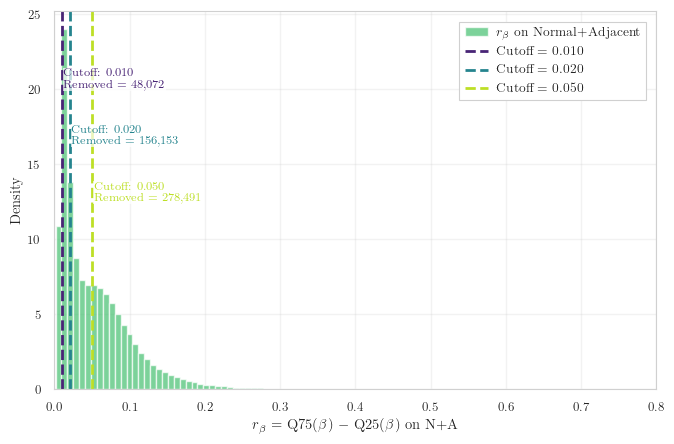

Saved: r_beta_distribution_NA_study.pdf


In [44]:
# OPTIONAL: PLOT r_beta DISTRIBUTION (N+A)
# Visualize r_beta distribution and the chosen cutoffs.

try:
    import matplotlib.pyplot as plt

    print("Generating r_beta distribution plot (Normal+Adjacent)...")

    cmap = plt.cm.get_cmap("viridis")
    hist_color = cmap(0.70)

    if "apply_thesis_style" in globals():
        apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

    plt.figure()
    plt.hist(beta_range, bins=HIST_BINS, density=True, alpha=0.7,
             color=hist_color, label=r"$r_{\beta}$ on Normal+Adjacent")

    y_top = plt.ylim()[1]
    y_idx = 0.85
    colors = [cmap(0.10), cmap(0.45), cmap(0.90)]

    for t, color in zip(THRESHOLDS, colors):
        removed = removed_counts[t]
        label_text = f"Cutoff: {t:.3f}\nRemoved = {removed:,}"
        plt.axvline(t, linestyle="--", linewidth=2, color=color, label=f"Cutoff = {t:.3f}")
        plt.text(
            t + 0.002, y_top * y_idx, label_text,
            color=color,
            ha="left", va="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.2),
        )
        y_idx -= 0.15

    plt.xlabel(r"$r_{\beta}$ = Q75($\beta$) − Q25($\beta$) on N+A")
    plt.ylabel("Density")
    plt.xlim(0, 0.8)

    if "place_legend" in globals():
        place_legend(position="upper right")
    else:
        plt.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig("r_beta_distribution_NA_study.pdf", bbox_inches="tight")
    plt.show()

    print("Saved: r_beta_distribution_NA_study.pdf")

except Exception as e:
    print(f"Skipping r_beta plot due to error: {e}")


In [45]:
# STEP 4 SUMMARY
# Summarize invariance filtering on Normal+Adjacent and final matrices.

removed_pct = (len(remove_cpgs_invariant) / n_total) * 100.0 if n_total > 0 else 0.0

print("\n=== STEP 4 — Invariance Filter Summary (Normal + Adjacent) ===")
print(f"Total CpGs analyzed (N+A):          {n_total:,}")
print(f"Invariance threshold r_beta >= {THRESH_TO_USE:.3f}")
print(f"CpGs removed (low variability N+A): {len(remove_cpgs_invariant):,} ({removed_pct:5.1f}%)")
print(f"CpGs kept:                          {len(keep_cpgs):,}")
print("Matrices ready:")
print("  • M_final_preFS       (M-values, batch-corrected, filtered)")
print("  • beta_final_preFS    (beta-values, post-technical, filtered)")
print("These will be used as inputs for feature selection and downstream analysis.")
print("===============================================================")



=== STEP 4 — Invariance Filter Summary (Normal + Adjacent) ===
Total CpGs analyzed (N+A):          486,725
Invariance threshold r_beta >= 0.020
CpGs removed (low variability N+A): 156,153 ( 32.1%)
CpGs kept:                          330,572
Matrices ready:
  • M_final_preFS       (M-values, batch-corrected, filtered)
  • beta_final_preFS    (beta-values, post-technical, filtered)
These will be used as inputs for feature selection and downstream analysis.


In [ ]:
# PRELIMINARY THRESHOLD STUDY
# Evaluate how many CpGs would be removed at different thresholds for r_beta.

print("\n=== Step 4.2 — Preliminary study for invariance thresholds (r_beta < t) ===")
removed_counts = {}

for t in THRESHOLDS:
    cnt = int(np.sum(beta_range < t))
    removed_counts[t] = cnt
    print(f"  Threshold t = {t:.3f}: removes {cnt:10,} / {n_total:,} CpGs ({cnt/n_total:6.1%})")


In [ ]:
# APPLY CHOSEN THRESHOLD AND BUILD KEEP MASK
# Apply final chosen threshold THRESH_TO_USE on r_beta, computed from Normal+Adjacent only.

mask_keep = beta_range >= THRESH_TO_USE

keep_cpgs = {cpg_cols[i] for i, keep in enumerate(mask_keep) if keep}
remove_cpgs_invariant = {cpg_cols[i] for i, keep in enumerate(mask_keep) if not keep}

print(f"\nApplied invariance threshold t = {THRESH_TO_USE:.3f}:")
print(f"  Removed (non-variable on N+A): {len(remove_cpgs_invariant):,} CpGs")
print(f"  Kept (variable on N+A):        {len(keep_cpgs):,} CpGs")


In [ ]:
# BUILD FINAL MATRICES M_final_preFS AND beta_final_preFS
# Apply keep_cpg mask to ALL samples (N + A + T) for both beta_clean and M_combat.

keep_cpgs_sorted = sorted(list(keep_cpgs))

M_final_preFS = lf_M_all.select(meta_cols + keep_cpgs_sorted)
beta_final_preFS = lf_beta_all.select(meta_cols + keep_cpgs_sorted)

print("\nFinal matrices for pre-feature-selection stage defined:")
print("  M_final_preFS  — M-values (batch-corrected), filtered CpGs, all samples.")
print("  beta_final_preFS — beta-values (post-technical), same CpGs, all samples.")


In [ ]:
# SAVE REMOVED INVARIANT CPGS
# Save list of CpGs removed by invariance filter for reproducibility and thesis reporting.

pl.DataFrame(
    {
        "CpG_removed_invariant": sorted(remove_cpgs_invariant),
        "reason": ["low_r_beta_on_NA"] * len(remove_cpgs_invariant),
        "threshold_r_beta": [THRESH_TO_USE] * len(remove_cpgs_invariant),
    }
).write_csv("cpg_removed_invariant_on_NA.csv")

print("Saved removed invariant CpGs to 'cpg_removed_invariant_on_NA.csv'.")


In [ ]:
# OPTIONAL: PLOT DISTRIBUTION OF r_beta
# Plot histogram of r_beta with vertical lines for study thresholds (if plotting utilities are available).

try:
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    print("Generating r_beta distribution plot...")

    cmap = plt.cm.get_cmap("viridis")
    hist_color = cmap(0.70)

    if "apply_thesis_style" in globals():
        apply_thesis_style(use_tex=True, legend_position="upper right", legend_outside=False)

    plt.figure()
    plt.hist(beta_range, bins=HIST_BINS, density=True, alpha=0.7,
             color=hist_color, label=r"$r_{\beta}$ on Normal+Adjacent")

    y_top = plt.ylim()[1]
    y_idx = 0.85
    colors = [cmap(0.10), cmap(0.45), cmap(0.90)]

    for t, color in zip(THRESHOLDS, colors):
        removed = removed_counts[t]
        label_text = f"Cutoff: {t:.3f}\nRemoved = {removed:,}"
        plt.axvline(t, linestyle="--", linewidth=2, color=color, label=f"Cutoff = {t:.3f}")
        plt.text(
            t + 0.002, y_top * y_idx, label_text,
            color=color,
            ha="left", va="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.2),
        )
        y_idx -= 0.15

    plt.xlabel(r"$r_{\beta}$ = Q75($\beta$) − Q25($\beta$) on N+A")
    plt.ylabel("Density")
    plt.xlim(0, 0.8)

    if "place_legend" in globals():
        place_legend(position="upper right")
    else:
        plt.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig("r_beta_distribution_NA_study.pdf", bbox_inches="tight")
    plt.show()

    print("Saved: r_beta_distribution_NA_study.pdf")

except Exception as e:
    print(f"Skipping r_beta plot due to error: {e}")


In [ ]:
# STEP 4 SUMMARY
# Summarize the invariance filter on Normal+Adjacent and final matrices for downstream analysis.

removed_pct = (len(remove_cpgs_invariant) / n_total) * 100.0 if n_total > 0 else 0.0

print("\n=== STEP 4 — Invariance Filter Summary (Normal + Adjacent) ===")
print(f"Total CpGs analyzed (N+A):          {n_total:,}")
print(f"Invariance threshold r_beta >= {THRESH_TO_USE:.3f}")
print(f"CpGs removed (low variability N+A): {len(remove_cpgs_invariant):,} ({removed_pct:5.1f}%)")
print(f"CpGs kept:                          {len(keep_cpgs):,}")
print("Matrices ready:")
print("  • M_final_preFS       (M-values, batch-corrected, filtered)")
print("  • beta_final_preFS    (beta-values, post-technical, filtered)")
print("These will be used as inputs for feature selection and downstream analysis.")
print("===============================================================")


## STEP 5

In [ ]:
# SAVE FINAL MATRICES FOR DOWNSTREAM ANALYSES
# Save beta_final_preFS and M_final_preFS as Parquet (LZ4) for feature selection and ML.

import polars as pl

DATASET_ID = "GSEXXXX"  # TODO: replace with e.g. "GSE69914", "GSE225845", ...

OUT_BETA_FINAL = f"/kaggle/working/{DATASET_ID}_beta_final_preFS_lz4.parquet"
OUT_M_FINAL    = f"/kaggle/working/{DATASET_ID}_M_final_preFS_lz4.parquet"

# Save beta_final_preFS
lf_beta_final = beta_final_preFS.lazy() if isinstance(beta_final_preFS, pl.DataFrame) else beta_final_preFS
try:
    lf_beta_final.sink_parquet(OUT_BETA_FINAL, compression="lz4", maintain_order=True)
    print(f"Saved beta_final_preFS to: {OUT_BETA_FINAL}")
except Exception as e:
    print(f"Warning: sink_parquet failed for beta_final_preFS with {e}. Falling back to collect().")
    df_beta_final = lf_beta_final.collect(streaming=True)
    df_beta_final.write_parquet(OUT_BETA_FINAL, compression="lz4")
    del df_beta_final
    print(f"Saved beta_final_preFS to: {OUT_BETA_FINAL} (via collect).")

# Save M_final_preFS
lf_M_final = M_final_preFS.lazy() if isinstance(M_final_preFS, pl.DataFrame) else M_final_preFS
try:
    lf_M_final.sink_parquet(OUT_M_FINAL, compression="lz4", maintain_order=True)
    print(f"Saved M_final_preFS to: {OUT_M_FINAL}")
except Exception as e:
    print(f"Warning: sink_parquet failed for M_final_preFS with {e}. Falling back to collect().")
    df_M_final = lf_M_final.collect(streaming=True)
    df_M_final.write_parquet(OUT_M_FINAL, compression="lz4")
    del df_M_final
    print(f"Saved M_final_preFS to: {OUT_M_FINAL} (via collect).")


In [ ]:
# BUILD GLOBAL REMOVED-CPG SUMMARY TABLE
# Aggregate all removed CpGs (technical + non-CpG + X/Y + invariant) with reason flags.

from typing import Dict, List, Set

# Union of technical + non-CpG + X/Y + invariant
all_removed_technical = (
    S_naeem
    | S_pidsley
    | S_zhou
    | S_chenx
    | S_mccartney
    | non_cpg_in_beta
    | xy_in_beta
)
all_removed_cpgs = all_removed_technical | remove_cpgs_invariant

print(f"Total CpGs removed by any filter (technical + invariant): {len(all_removed_cpgs):,}")

rows: List[Dict[str, int | str]] = []
for cg in sorted(all_removed_cpgs):
    rows.append(
        {
            "CpG_ID": cg,
            "From_Naeem":      int(cg in S_naeem),
            "From_Pidsley":    int(cg in S_pidsley),
            "From_Zhou":       int(cg in S_zhou),
            "From_ChenX":      int(cg in S_chenx),
            "From_McCartney":  int(cg in S_mccartney),
            "From_Non_CpG":    int(cg in non_cpg_in_beta),
            "From_XY":         int(cg in xy_in_beta),
            "From_Invariant":  int(cg in remove_cpgs_invariant),
        }
    )

removed_all_df = pl.DataFrame(rows).with_columns(
    (
        pl.col("From_Naeem")
        + pl.col("From_Pidsley")
        + pl.col("From_Zhou")
        + pl.col("From_ChenX")
        + pl.col("From_McCartney")
        + pl.col("From_Non_CpG")
        + pl.col("From_XY")
        + pl.col("From_Invariant")
    ).alias("Source_Count")
)

removed_all_df = removed_all_df.sort(["Source_Count", "CpG_ID"], descending=[True, False])

OUT_REMOVED_ALL = f"/kaggle/working/{DATASET_ID}_cpg_removed_all_filters_summary.csv"
removed_all_df.write_csv(OUT_REMOVED_ALL)

print(f"Saved global removed-CpG summary to: {OUT_REMOVED_ALL}")
print("Columns: CpG_ID + flags (Naeem, Pidsley, Zhou, ChenX, McCartney, Non_CpG, XY, Invariant) + Source_Count.")


In [ ]:
# SAVE KEPT CpGs AFTER ALL FILTERS
# Save the list of CpGs retained in beta_final_preFS for reproducibility.

# Collect final CpG list from beta_final_preFS
beta_final_schema = list(lf_beta_final.schema.keys())
final_cpg_cols = [
    c for c in beta_final_schema
    if isinstance(c, str) and (c.startswith("cg") or c.startswith("ch"))
]

OUT_KEPT_CPGS = f"/kaggle/working/{DATASET_ID}_cpg_kept_final_preFS.csv"
pl.DataFrame({"CpG_kept_final_preFS": sorted(final_cpg_cols)}).write_csv(OUT_KEPT_CPGS)

print(f"Saved kept CpGs (final pre-FS set) to: {OUT_KEPT_CPGS}")
print(f"Total kept CpGs (after technical + invariants): {len(final_cpg_cols):,}")


In [ ]:
# PER-STEP NUMERICAL SUMMARY
# Print a compact summary of CpG counts per filtering step (where available).

# Initial CpG count (from technical filter step)
if "filter_stats" in globals() and "initial_cpgs" in filter_stats:
    initial_cpgs = filter_stats["initial_cpgs"]
else:
    # Fallback: count CpGs before technical filtering is not available here
    initial_cpgs = None

# CpGs after technical filtering (before invariance)
cpg_after_technical = filter_stats.get("final_cpgs", None) if "filter_stats" in globals() else None

# CpGs removed by invariance filter (we know this exactly)
removed_invariant = len(remove_cpgs_invariant)
cpg_after_invariant = len(final_cpg_cols)

print("\n=== STEP 5 — CpG Count Summary ===")
if initial_cpgs is not None:
    print(f"Initial CpGs (raw after NaN/Type filter): {initial_cpgs:,}")
else:
    print("Initial CpGs:               (not available in this scope)")

if "filter_stats" in globals():
    print(f"Removed by Naeem:           {filter_stats.get('removed_naeem', 0):,}")
    print(f"Removed by Pidsley:         {filter_stats.get('removed_pidsley', 0):,}")
    print(f"Removed by Zhou:            {filter_stats.get('removed_zhou', 0):,}")
    print(f"Removed by ChenX:           {filter_stats.get('removed_chenx', 0):,}")
    print(f"Removed by McCartney:       {filter_stats.get('removed_mccartney', 0):,}")
    print(f"Removed by Non-CpG:         {filter_stats.get('removed_non_cpg', 0):,}")
    print(f"Removed by X/Y:             {filter_stats.get('removed_xy', 0):,}")
    if cpg_after_technical is not None:
        print(f"CpGs after technical filter:{cpg_after_technical:,}")

print(f"Removed by invariance (N+A): {removed_invariant:,}")
print(f"CpGs after invariance:       {cpg_after_invariant:,}")
print("These CpGs define beta_final_preFS and M_final_preFS for downstream analyses.")
print("=========================================================")


In [ ]:
# MINI-REPORT SUMMARY OBJECTS
# Build small summary tables for samples and CpGs that can be reused in markdown/LaTeX.

# Sample counts per label after full preprocessing
df_labels = lf_beta_final.select(pl.col("label")).collect()
label_counts = (
    df_labels
    .with_columns(pl.col("label").cast(pl.Int64))
    .group_by("label")
    .len()
    .rename({"len": "n_samples"})
    .sort("label")
)

print("\nSample counts per label (after full QC):")
print(label_counts)

# CpG-by-step summary (where info is available)
summary_rows = []

if initial_cpgs is not None:
    summary_rows.append({"step": "Initial (post-NaN)", "n_cpgs": initial_cpgs})
if cpg_after_technical is not None:
    summary_rows.append({"step": "After technical filter", "n_cpgs": cpg_after_technical})

summary_rows.append({"step": "After invariance (pre-FS)", "n_cpgs": cpg_after_invariant})

summary_df = pl.DataFrame(summary_rows)

OUT_STEP_SUMMARY = f"/kaggle/working/{DATASET_ID}_cpg_step_summary.csv"
summary_df.write_csv(OUT_STEP_SUMMARY)

print(f"\nSaved step-wise CpG summary to: {OUT_STEP_SUMMARY}")
print("You can directly reuse this table in the thesis (e.g., '850k → 720k → 500k ...').")
